In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

In [ ]:
# give colab access to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/tmp/ipython-input-3450780785.py:81: RuntimeWarning: invalid value encountered in log
  plt.imshow(np.log(autocorr+ 1), cmap='gray')


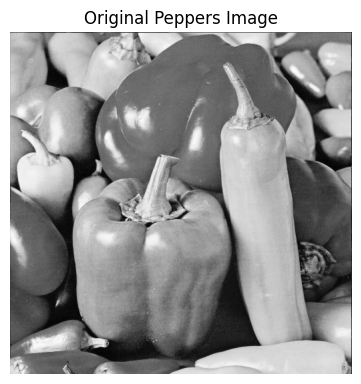

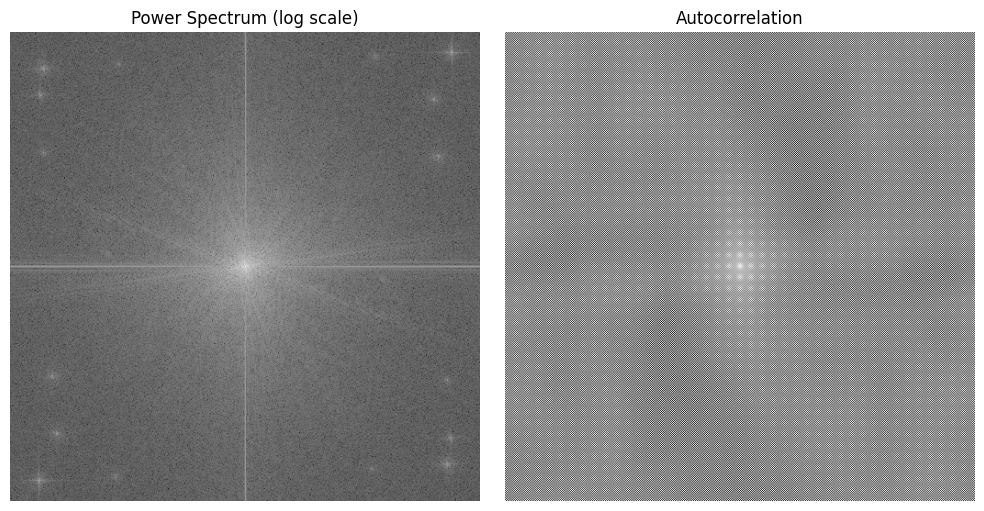

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.signal import correlate2d

# image path
work_path = '/content/drive/MyDrive/DigitalImageProcessing/Chapter 3 Background/'

def calculate_autocorrelation_and_power_spectrum(image_path):

    # Load the image (assuming grayscale for simplicity, convert if needed)
    try:
        # Check if the file is a .mat file
        if image_path.lower().endswith('.mat'):
            mat_data = sio.loadmat(image_path)
            # Use the correct key 'peppers' to load the image data
            image = mat_data['peppers']
        else:
            image = plt.imread(image_path)

        if image.ndim == 3:  # Convert to grayscale if it's a color image
            image = np.mean(image, axis=2)
    except FileNotFoundError:
        print(f"Error: Image file not found at {image_path}")
        return None, None
    except KeyError:
        print(f"Error: Could not find 'peppers' variable in the .mat file at {image_path}")
        return None, None


    # 1. Power Spectrum
    # Compute the 2-D FFT of the image
    fourier_transform = np.fft.fft2(image)
    # Shift the zero-frequency component to the center
    fourier_transform_shifted = np.fft.fftshift(fourier_transform)
    # Calculate the power spectrum (magnitude squared)
    power_spectrum_image = np.abs(fourier_transform_shifted)**2

    # 2. Autocorrelation
    # Autocorrelation can be computed as the inverse FFT of the power spectrum
    # Alternatively, you can use scipy.signal.correlate2d for direct computation
    # For a more direct link to the power spectrum, we use the FFT approach
    autocorrelation_image = np.fft.ifft2(power_spectrum_image).real
    # Shift the zero-frequency component to the center for visualization
    autocorrelation_image = np.fft.fftshift(autocorrelation_image)

    return autocorrelation_image, power_spectrum_image

if __name__ == "__main__":
    # Example usage: Replace 'your_image.png' with the actual path to your image
    image_file = work_path + 'Data/peppers.mat'
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    # Check if the file is a .mat file before using plt.imread
    if image_file.lower().endswith('.mat'):
        mat_data = sio.loadmat(image_file)
        # Use the correct key 'peppers' to load the image data
        original_image = mat_data['peppers']
        if original_image.ndim == 3:
             original_image = np.mean(original_image, axis=2)
    else:
        original_image = plt.imread(image_file)

    plt.imshow(original_image, cmap='gray')
    plt.title('Original Peppers Image')
    plt.axis('off')

    autocorr, power_spec = calculate_autocorrelation_and_power_spectrum(image_file)

    if autocorr is not None and power_spec is not None:
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 2)
        plt.imshow(np.log(power_spec + 1), cmap='gray')
        plt.title('Power Spectrum (log scale)')
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(np.log(autocorr+ 1), cmap='gray')
        plt.title('Autocorrelation')
        plt.axis('off')

        plt.tight_layout()
        plt.show()

In [ ]:
import scipy.io as sio

image_file = work_path + 'Data/Peppers.mat'
try:
    mat_data = sio.loadmat(image_file)
    print("Keys available in the .mat file:")
    for key in mat_data:
        print(key)
except FileNotFoundError:
    print(f"Error: Image file not found at {image_file}")

Keys available in the .mat file:
__header__
__version__
__globals__
peppers
